In [22]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names)
df["target"] = data.target

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(predictions)
print(y_test)
accuracy = accuracy_score(y_test, predictions)
print(accuracy)

[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]
204    1
70     0
131    0
431    1
540    1
      ..
486    1
75     0
249    1
238    1
265    0
Name: target, Length: 114, dtype: int64
0.9649122807017544


In [23]:
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values("importance", ascending = False)

print(feature_importance_df.head(10))

                 feature  importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


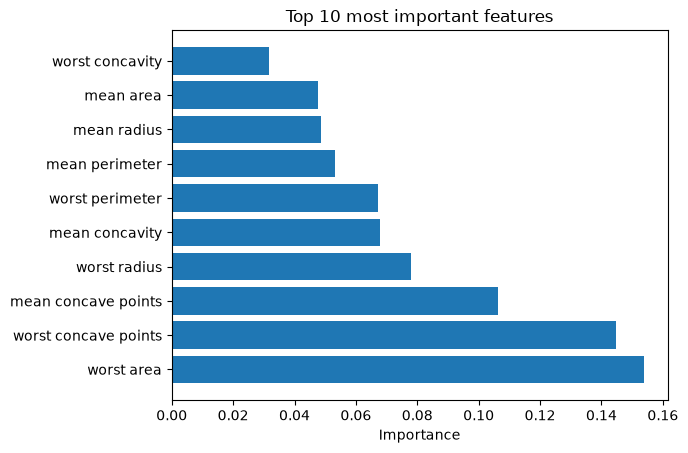

In [24]:
import matplotlib.pyplot as plt

top_10 = feature_importance_df.head(10)
plt.barh(top_10["feature"], top_10["importance"])
plt.xlabel("Importance")
plt.title("Top 10 most important features")
plt.show()

the most important sign for predicting breast cancer in this datas is worst area. the second and third ones are worst concave points and mean concave points.

In [25]:
print(df[["worst area", "mean area", "target"]].corr())

            worst area  mean area    target
worst area    1.000000   0.959213 -0.733825
mean area     0.959213   1.000000 -0.708984
target       -0.733825  -0.708984  1.000000
